# 03 - A/B test: onboarding redesign (EXP-ONB-2026-01)
_Synthetic data._

Control = existing onboarding; treatment = trust signals + DigiLocker one-tap + progress indicator. Primary metric: KYC completed within 7 days of signup.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from python import visualize as viz   # shared chart style (palette, fonts, grid)
%matplotlib inline
from python.config import get_settings
S = get_settings(base_dir=ROOT)
con = duckdb.connect(str(S.warehouse_path), read_only=True)
q = lambda sql: con.execute(sql).df()
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
print("Warehouse:", S.warehouse_path.name, "| as of", S.end_date, "| SYNTHETIC DATA")

Warehouse: fintech.duckdb | as of 2026-06-30 | SYNTHETIC DATA


In [2]:
from python.experiment_analysis import ONB_SQL, two_proportion_test, required_n_per_arm, achieved_power, srm_check, bayes_beta_binomial
units = q(ONB_SQL)
units.groupby('variant').agg(users=('customer_id','size'), kyc_7d=('kyc_7d','mean'), app_14d=('app_14d','mean'), disb_30d=('disb_30d','mean'))

,users,kyc_7d,app_14d,disb_30d
variant,,,,
control,2543,0.585136,0.302006,0.152576
treatment,2407,0.617781,0.316577,0.174076


## 1. Validity first: sample-ratio mismatch

In [3]:
n = units.variant.value_counts(); srm_check(int(n['control']), int(n['treatment']))

{'control_n': 2543,
 'treatment_n': 2407,
 'treatment_share': 0.4862626262626263,
 'chi_square': 3.7365656565656566,
 'p_value': 0.053233755221521045,
 'srm_detected': False}

## 2. Primary metric: two-proportion z-test, by hand and via the library

In [4]:
g = units.groupby('variant').kyc_7d.agg(['sum','count'])
xc, nc, xt, nt = g.loc['control','sum'], g.loc['control','count'], g.loc['treatment','sum'], g.loc['treatment','count']
pc, pt = xc/nc, xt/nt; p = (xc+xt)/(nc+nt)
z = (pt-pc)/np.sqrt(p*(1-p)*(1/nc+1/nt))
print(f'control {pc:.4f}  treatment {pt:.4f}  diff {100*(pt-pc):+.2f} pp  z={z:.2f}')
two_proportion_test(int(xc), int(nc), int(xt), int(nt))

control 0.5851  treatment 0.6178  diff +3.26 pp  z=2.34


{'control_n': 2543,
 'control_x': 1488,
 'control_rate': 0.5851356665355879,
 'treatment_n': 2407,
 'treatment_x': 1487,
 'treatment_rate': 0.6177814707104279,
 'diff_abs': 0.032645804174839976,
 'ci_low': 0.0053776952683993635,
 'ci_high': 0.05991391308128059,
 'relative_uplift': 0.055791854849877726,
 'rel_ci_low': 0.008961012573513116,
 'rel_ci_high': 0.10479634681238803,
 'z': 2.3443052539154974,
 'p_value': 0.019062562722982124,
 'significant': True}

## 3. Power: was the test big enough?

baseline 0.5743 | MDE 0.04 | required n/arm 2365 | weeks needed 6


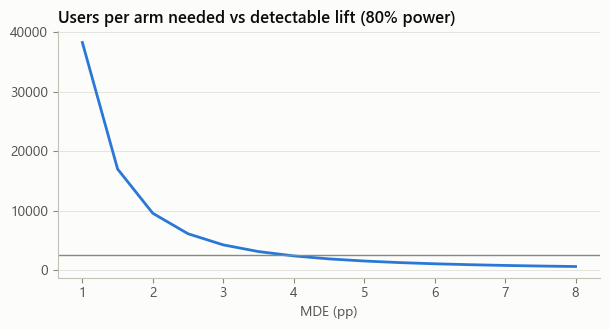

In [5]:
res = json.loads((S.outputs_dir/'experiments'/'experiment_results.json').read_text())['EXP-ONB-2026-01']
d = res['design']; print('baseline', round(d['pre_period_baseline'],4), '| MDE', d['planned_mde_abs'], '| required n/arm', d['required_n_per_arm'], '| weeks needed', d['weeks_needed'])
mdes = np.linspace(0.01, 0.08, 15)
plt.figure(figsize=(7,3.2)); plt.plot(100*mdes, [required_n_per_arm(d['pre_period_baseline'], m) for m in mdes], color=viz.SERIES[0])
plt.axhline(nc, color=viz.MUTED, lw=1); plt.title('Users per arm needed vs detectable lift (80% power)'); plt.xlabel('MDE (pp)'); plt.show()

## 4. Guardrails, Bayesian view and heterogeneity

In [6]:
pd.DataFrame(res['guardrails']).T[['control_rate','treatment_rate','diff_abs','ci_low','ci_high','margin','status']]

,control_rate,treatment_rate,diff_abs,ci_low,ci_high,margin,status
approval_rate,0.518129,0.549425,0.031297,-0.015765,0.078359,0.02,pass
fpd30_rate,0.032037,0.017279,-0.014758,-0.035092,0.005576,0.015,pass
kyc_support_ticket_rate,0.034998,0.03656,0.001562,-0.008793,0.011917,0.01,inconclusive


In [7]:
res['bayesian']

{'prob_treatment_better': 0.9903,
 'expected_loss_if_ship': 4.638364496089977e-05,
 'credible_low': 0.00524293744587622,
 'credible_high': 0.059702741225447165}

In [8]:
pd.DataFrame(res['segments'])[['dimension','segment','users','diff_abs','ci_low','ci_high','p_value_holm']]

,dimension,segment,users,diff_abs,ci_low,ci_high,p_value_holm
0,platform,android,4007,0.031786,0.001379,0.062193,0.162746
1,platform,ios,943,0.031679,-0.029967,0.093326,0.856882
2,city_tier,tier_1,2307,0.044325,0.004493,0.084158,0.147435
3,city_tier,tier_2,1704,0.025359,-0.021175,0.071893,0.856882
4,city_tier,tier_3,939,0.017663,-0.045235,0.080560,0.856882


In [9]:
from IPython.display import Markdown
Markdown((S.outputs_dir/'experiments'/'EXP-ONB-2026-01_readout.md').read_text())

# Experiment readout - EXP-ONB-2026-01

_Onboarding redesign: trust signals + progress indicator. Synthetic data; generated by `python/experiment_analysis.py`._

**Decision: SHIP with post-launch monitoring of kyc_support_ticket_rate**

## Design (pre-registered)

| Item | Value |
|---|---|
| Unit / allocation | new app signup (android/ios), 50/50 random at first app open |
| Window | 2026-01-12 to 2026-02-22 (6 weeks) |
| Primary metric | KYC completed within 7 days of signup |
| Baseline (pre-period) | 57.43% |
| MDE / alpha / power | 4.0 pp / 0.05 / 80% |
| Required sample | 2,365 per arm (~6 weeks at 803 app signups/week) |

## Validity checks

- Sample ratio: control 2,543 vs treatment 2,407 (treatment share 48.63%), chi-square p = 0.053 -> no sample-ratio mismatch.
- Novelty check: weekly effects range from +0.86 pp to +6.06 pp; no decay pattern is required for a ship decision but is monitored.

## Results

| Metric | Control | Treatment | Difference (95% CI) | Relative uplift | p-value |
|---|---:|---:|---|---:|---:|
| **KYC completed in 7 days (primary)** | 58.51% | 61.78% | +3.26 pp (+0.54 pp to +5.99 pp) | +5.6% | 0.0191 |
| application submitted 14d | 30.20% | 31.66% | +1.46 pp (-1.12 pp to +4.03 pp) | +4.8% | 0.2675 |
| loan disbursed 30d | 15.26% | 17.41% | +2.15 pp (+0.09 pp to +4.21 pp) | +14.1% | 0.0407 |

Bayesian view: P(treatment better) = 99.0%, expected loss if shipped = 0.005 pp.
Achieved power at the observed effect = 64%; MDE at the realised sample = 3.95 pp.

## Guardrails (non-inferiority)

| Guardrail | Control | Treatment | Difference (95% CI) | Margin | Status |
|---|---:|---:|---|---:|---|
| approval rate | 51.81% | 54.94% | +3.13 pp (-1.58 pp to +7.84 pp) | 2.0 pp | pass |
| fpd30 rate | 3.20% | 1.73% | -1.48 pp (-3.51 pp to +0.56 pp) | 1.5 pp | pass |
| kyc support ticket rate | 3.50% | 3.66% | +0.16 pp (-0.88 pp to +1.19 pp) | 1.0 pp | inconclusive |

## Heterogeneity (exploratory, Holm-adjusted)

| Segment | Users | Difference | 95% CI | Holm p |
|---|---:|---:|---|---:|
| platform = android | 4,007 | +3.18 pp | +0.14 pp to +6.22 pp | 0.1627 |
| platform = ios | 943 | +3.17 pp | -3.00 pp to +9.33 pp | 0.8569 |
| city_tier = tier_1 | 2,307 | +4.43 pp | +0.45 pp to +8.42 pp | 0.1474 |
| city_tier = tier_2 | 1,704 | +2.54 pp | -2.12 pp to +7.19 pp | 0.8569 |
| city_tier = tier_3 | 939 | +1.77 pp | -4.52 pp to +8.06 pp | 0.8569 |

## Business impact (estimate)

- ~1,502 additional verified customers per year at the post-launch app-signup run rate.
- ~387 additional first loans per year (KYC -> first loan within 30 days: 25.75%).
- ~â‚¹16.59 L additional net revenue per year from first loans alone (â‚¹4,288 per first loan).
- Assumptions: Uplift applied to the post-rollout app-signup run rate; downstream conversion and revenue per first loan held at historical averages (no repeat-loan value counted - conservative).

## Assumptions

- Randomisation at the customer level is independent of outcome drivers (checked with the SRM test and balanced platform mix).
- No interference between units (one customer's onboarding does not change another's) and a single, stable treatment version during the test (SUTVA).
- Fixed horizon: the readout is computed once at the planned end date - no peeking-based early stopping, so the nominal 5% false-positive rate holds.
- Normal approximation to the binomial is valid (thousands of users per arm, rates far from 0 and 1).
- Guardrails are judged by non-inferiority margins agreed before launch, not by significance alone.

## Limitations

- Downstream metrics (loans, FPD30) are diluted by the many steps after KYC, so the test is not powered for them; FPD30 is monitored post-launch rather than decided on.
- Web signups were not eligible; the web flow needs its own test.
- Segment results are exploratory (multiple comparisons) and should not drive targeting without a follow-up test.
- Customers were assigned at first app open; users who reinstalled could in principle see both variants (assignment is keyed on customer_id, so exposure is stable after signup).
- Effects can shrink after launch (novelty, seasonality); the KYC weekly trend is tracked against the pre-period.
